# NASA Turbofan Jet Engine - Data Validation & EDA

**Dataset:** C-MAPSS (Commercial Modular Aero-Propulsion System Simulation)  
**Goal:** Predict Remaining Useful Life (RUL) of turbofan jet engines  

| Dataset | Train Engines | Test Engines | Conditions | Fault Modes |
|---------|--------------|-------------|------------|-------------|
| FD001   | 100          | 100         | 1 (Sea Level) | 1 (HPC Degradation) |
| FD002   | 260          | 259         | 6          | 1 (HPC Degradation) |
| FD003   | 100          | 100         | 1 (Sea Level) | 2 (HPC + Fan) |
| FD004   | 248          | 249         | 6          | 2 (HPC + Fan) |

**Columns (26):** unit_id, cycle, op_setting_1-3, sensor_1-21

## 1. Setup & Load Data

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color palette
COLORS = sns.color_palette('husl', 8)
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [248]:
# Define column names
col_names = ['unit_id', 'cycle'] + \
            [f'op_setting_{i}' for i in range(1, 4)] + \
            [f'sensor_{i}' for i in range(1, 22)]

DATA_DIR = 'CMaps'

# Load all datasets
datasets = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    # Resolve dataset folder robustly (handles different notebook working directories)
    candidate_dirs = [
        DATA_DIR,
        os.path.join('.', DATA_DIR),
        os.path.join('..', DATA_DIR),
        os.getcwd(),
        os.path.join(os.getcwd(), DATA_DIR),
    ]

    loaded = False
    checked_paths = []
    for base_dir in dict.fromkeys(candidate_dirs):  # remove duplicates, keep order
        train_path = os.path.join(base_dir, f'train_{fd}.txt')
        test_path  = os.path.join(base_dir, f'test_{fd}.txt')
        rul_path   = os.path.join(base_dir, f'RUL_{fd}.txt')
        checked_paths.append((train_path, test_path, rul_path))

        if all(os.path.isfile(p) for p in [train_path, test_path, rul_path]):
            datasets[fd] = {
                'train': pd.read_csv(train_path, sep=r'\s+', header=None, names=col_names),
                'test':  pd.read_csv(test_path,  sep=r'\s+', header=None, names=col_names),
                'rul':   pd.read_csv(rul_path,   sep=r'\s+', header=None, names=['RUL'])
            }
            loaded = True
            break

    if not loaded:
        raise FileNotFoundError(
            f"Could not find files for {fd}. Current working directory: {os.getcwd()}\n"
            f"Checked:\n" + "\n".join([f"  - {t}\n    {te}\n    {r}" for t, te, r in checked_paths])
        )

print('All 4 sub-datasets (train, test, RUL for each) have been loaded.')
print(f'Columns: {col_names}')

All 4 sub-datasets (train, test, RUL for each) have been loaded.
Columns: ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


# Data processing

## **1.**

In [249]:
# ============================================================
# TASK 1.1 — INITIALIZING PIECEWISE RUL LABEL
# ============================================================

# Piecewise RUL threshold
MAX_RUL = 125

target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

for fd in target_fds:

    print(f"\n[{fd}] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = {MAX_RUL})")

    train_df = datasets[fd]['train']

    # 1. Find maximum lifetime of each engine
    max_cycle_df = (
        train_df.groupby('unit_id')['cycle']
        .max()
        .reset_index()
    )

    max_cycle_df.columns = ['unit_id', 'max_cycle']

    # 2. Merge back to original dataframe
    train_df = train_df.merge(
        max_cycle_df,
        on='unit_id',
        how='left'
    )

    # 3. Compute linear RUL
    train_df['RUL'] = (
        train_df['max_cycle'] - train_df['cycle']
    )

    # 4. Apply Piecewise RUL clipping
    train_df['RUL'] = train_df['RUL'].clip(
        upper=MAX_RUL
    )

    # 5. Remove temporary column
    train_df.drop(columns=['max_cycle'], inplace=True)

    # Update dataset
    datasets[fd]['train'] = train_df

    # Verification
    print(f"Successfully created RUL label. Train set size: {train_df.shape}")

    print(f"Verifying RUL for unit_id = 1:")

    display_df = pd.concat([
        train_df[train_df['unit_id'] == 1].head(3),
        train_df[train_df['unit_id'] == 1].tail(3)
    ])

    print(
        display_df[
            ['unit_id', 'cycle', 'RUL']
        ].to_string(index=False)
    )

print("\n" + "="*60)
print("Piecewise RUL labeling complete!")


[FD001] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (20631, 27)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    190    2
       1    191    1
       1    192    0

[FD002] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (53759, 27)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    147    2
       1    148    1
       1    149    0

[FD003] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label. Train set size: (24720, 27)
Verifying RUL for unit_id = 1:
 unit_id  cycle  RUL
       1      1  125
       1      2  125
       1      3  125
       1    257    2
       1    258    1
       1    259    0

[FD004] TASK 1.1: INITIALIZING PIECEWISE RUL LABEL (MAX = 125)
Successfully created RUL label

In [250]:
# ============================================================
# TASK 1.2 — SENSOR AND FEATURE FILTERING
# ============================================================

from scipy.stats import spearmanr
import numpy as np
import pandas as pd

target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
op_cols = [f'op_setting_{i}' for i in range(1, 4)]

# FD002 & FD004 contain multiple operating conditions
MULTI_CONDITION_FDS = ['FD002', 'FD004']

for fd in target_fds:

    print(f"\n{'='*10} [{fd}] TASK 1.2: SENSOR AND FEATURE FILTERING {'='*10}")

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    cols_to_drop = []

    # ========================================================
    # 1. HANDLE OPERATING SETTINGS
    # ========================================================

    # FD001 & FD003:
    # only one operating condition
    # -> operating settings are not useful

    if fd not in MULTI_CONDITION_FDS:

        cols_to_drop.extend(op_cols)

    # ========================================================
    # 2. REMOVE TRULY CONSTANT FEATURES
    # ========================================================

    feature_cols = [
        col for col in train_df.columns
        if col.startswith('sensor_') or col.startswith('op_setting_')
    ]

    std_vals = train_df[feature_cols].std()

    constant_cols = std_vals[
        np.isclose(std_vals, 0)
    ].index.tolist()

    cols_to_drop.extend(constant_cols)

    # ========================================================
    # 3. ANALYZE LOW-VARIANCE SENSORS USING RUL
    # ========================================================

    near_constant_cols = std_vals[
        (std_vals > 0) & (std_vals < 0.01)
    ].index.tolist()

    kept_near_constant = []

    for col in near_constant_cols:

        engine_corrs = []

        for unit_id, group in train_df.groupby('unit_id'):

            if len(group) < 5:
                continue

            corr, _ = spearmanr(
                group[col],
                group['RUL']
            )

            if not pd.isna(corr):

                engine_corrs.append(abs(corr))

        avg_corr = np.mean(engine_corrs) if engine_corrs else 0

        # Weak degradation relationship
        if avg_corr < 0.2:

            cols_to_drop.append(col)

        else:

            kept_near_constant.append((col, avg_corr))

    # Remove duplicates
    cols_to_drop = list(set(cols_to_drop))

    # ========================================================
    # 4. APPLY DROP
    # ========================================================

    datasets[fd]['train'] = train_df.drop(columns=cols_to_drop)
    datasets[fd]['test'] = test_df.drop(columns=cols_to_drop)

    # ========================================================
    # 5. LOGGING
    # ========================================================

    print(f"\nDropped constant columns:")
    print(constant_cols)

    dropped_near = [
        c for c in cols_to_drop
        if c not in constant_cols and c not in op_cols
    ]

    print(f"\nDropped near-constant noisy sensors:")
    print(dropped_near)

    if kept_near_constant:

        print(f"\nSuccessfully KEPT near-constant sensors (with degradation trend):")

        for col, corr in kept_near_constant:

            print(f"    -> {col} (Avg Spearman corr with RUL: {corr:.4f})")

    print(f"\nFinal train shape: {datasets[fd]['train'].shape}")
    print(f"Final test shape : {datasets[fd]['test'].shape}")

print("\n" + "="*60)
print("Cleaning process complete! Useful sensors have been preserved.")


========== [FD001] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped constant columns:
['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Dropped near-constant noisy sensors:
['sensor_6']

Final train shape: (20631, 17)
Final test shape : (13096, 16)

========== [FD002] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped constant columns:
[]

Dropped near-constant noisy sensors:
['sensor_16']

Final train shape: (53759, 26)
Final test shape : (33991, 25)

========== [FD003] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped constant columns:
['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']

Dropped near-constant noisy sensors:
[]

Successfully KEPT near-constant sensors (with degradation trend):
    -> sensor_10 (Avg Spearman corr with RUL: 0.7749)

Final train shape: (24720, 19)
Final test shape : (16596, 18)

========== [FD004] TASK 1.2: SENSOR AND FEATURE FILTERING ==========

Dropped 

In [251]:
print(datasets['FD001']['train'].columns.tolist())

['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']


In [252]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

print("STARTING OPERATING CONDITION PROCESSING FOR FD002 & FD004")

# FD002 & FD004:
# multiple operating conditions
complex_fds = ['FD002', 'FD004']

op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Common practice in C-MAPSS literature
NUM_REGIMES = 6

for fd in complex_fds:

    print(f"\n{'='*15} CLUSTERING & NORMALIZING {fd} {'='*15}")

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    # =========================================================
    # 1. GET FILTERED SENSOR COLUMNS
    # =========================================================

    sensor_cols = [
        col for col in train_df.columns
        if col.startswith('sensor_')
    ]

    train_df[sensor_cols] = train_df[sensor_cols].astype(np.float32)
    test_df[sensor_cols] = test_df[sensor_cols].astype(np.float32)
    # =========================================================
    # 2. NORMALIZE OPERATING SETTINGS FOR K-MEANS
    # =========================================================

    print("1. Scaling operating settings...")

    op_scaler = StandardScaler()

    train_op_scaled = op_scaler.fit_transform(
        train_df[op_cols]
    )

    test_op_scaled = op_scaler.transform(
        test_df[op_cols]
    )

    # =========================================================
    # 3. K-MEANS CLUSTERING
    # =========================================================

    print(f"2. Performing K-Means clustering ({NUM_REGIMES} regimes)...")

    kmeans = KMeans(
        n_clusters=NUM_REGIMES,
        random_state=42,
        n_init=10
    )

    train_df['regime'] = kmeans.fit_predict(
        train_op_scaled
    )

    test_df['regime'] = kmeans.predict(
        test_op_scaled
    )

    # =========================================================
    # 4. CONDITION-BASED SENSOR NORMALIZATION
    # =========================================================

    print("3. Performing regime-based sensor normalization...")

    regime_scalers = {}

    for regime in range(NUM_REGIMES):

        train_idx = train_df[
            train_df['regime'] == regime
        ].index

        test_idx = test_df[
            test_df['regime'] == regime
        ].index

        # Skip empty train regime
        if len(train_idx) == 0:
            continue

        scaler = StandardScaler()

        # Fit on train regime only
        train_scaled = scaler.fit_transform(
            train_df.loc[train_idx, sensor_cols]
        )

        train_df.loc[train_idx, sensor_cols] = (
            train_scaled.astype(np.float32)
        )

        # Transform test regime
        if len(test_idx) > 0:

            test_scaled = scaler.transform(
                test_df.loc[test_idx, sensor_cols]
            )

            test_df.loc[test_idx, sensor_cols] = (
                test_scaled.astype(np.float32)
            )

        # Save scaler
        regime_scalers[regime] = scaler
    
    print("3.5 Cleaning sensors that became constant after regime-based scaling...")
    
    # Tính độ lệch chuẩn sau khi đã chuẩn hóa theo từng regime
    std_after = train_df[sensor_cols].std()
    
    # Tìm các cột có std gần bằng 0 hoặc bị NaN (do toàn bộ giá trị giống hệt nhau)
    post_constant_cols = std_after[
        np.isclose(std_after, 0) | std_after.isna()
    ].index.tolist()
    
    if post_constant_cols:
        print(f"    -> Dropping {len(post_constant_cols)} sensors that are constant per regime:")
        print(f"       {post_constant_cols}")
        
        train_df.drop(columns=post_constant_cols, inplace=True)
        test_df.drop(columns=post_constant_cols, inplace=True)
        
        # Cập nhật lại danh sách sensor_cols để tránh lỗi ở các bước sau (nếu cần)
        sensor_cols = [c for c in sensor_cols if c not in post_constant_cols]
    else:
        print("    -> No additional constant sensors detected.")

    # =========================================================
    # 5. SAVE OBJECTS FOR REPRODUCIBILITY
    # =========================================================

    datasets[fd]['kmeans'] = kmeans
    datasets[fd]['op_scaler'] = op_scaler
    datasets[fd]['regime_scalers'] = regime_scalers


    print("\nRegime distribution (train):")

    # =========================================================
    # 6. LOGGING
    # =========================================================

    print(
        train_df['regime'].value_counts()
        if 'regime' in train_df.columns
        else "Regime column removed after normalization."
    )

    # =========================================================
    # 7. CLEAN TEMP COLUMN
    # =========================================================

    # Keep op_settings for future analysis/debugging
    train_df.drop(columns=['regime'], inplace=True)
    test_df.drop(columns=['regime'], inplace=True)

    # =========================================================
    # 8. SAVE BACK
    # =========================================================

    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df


    print("\nNormalization complete.")
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape : {test_df.shape}")

print("\n" + "="*60)
print("Operating condition processing completed successfully.")

STARTING OPERATING CONDITION PROCESSING FOR FD002 & FD004

=============== CLUSTERING & NORMALIZING FD002 ===============
1. Scaling operating settings...
2. Performing K-Means clustering (6 regimes)...
3. Performing regime-based sensor normalization...
3.5 Cleaning sensors that became constant after regime-based scaling...
    -> Dropping 4 sensors that are constant per regime:
       ['sensor_1', 'sensor_5', 'sensor_18', 'sensor_19']

Regime distribution (train):
regime
0    13458
2     8122
4     8096
1     8044
5     8037
3     8002
Name: count, dtype: int64

Normalization complete.
Train shape: (53759, 22)
Test shape : (33991, 21)

=============== CLUSTERING & NORMALIZING FD004 ===============
1. Scaling operating settings...
2. Performing K-Means clustering (6 regimes)...
3. Performing regime-based sensor normalization...
3.5 Cleaning sensors that became constant after regime-based scaling...
    -> Dropping 4 sensors that are constant per regime:
       ['sensor_1', 'sensor_5', 

In [253]:
from sklearn.preprocessing import StandardScaler

simple_fds = ['FD001', 'FD003']

for fd in simple_fds:
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Lấy danh sách sensor hiện có (sau khi đã lọc constants ở Task 1.2)
    sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
    
    scaler = StandardScaler()
    
    # Fit & Transform cho Train
    train_df[sensor_cols] = scaler.fit_transform(train_df[sensor_cols]).astype(np.float32)
    
    # Chỉ Transform cho Test
    test_df[sensor_cols] = scaler.transform(test_df[sensor_cols]).astype(np.float32)
    
    # Lưu lại scaler nếu cần dùng sau này
    datasets[fd]['scaler'] = scaler

In [254]:
# ============================================================
# FINAL DTYPE UNIFICATION
# ============================================================

for fd in target_fds:

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    # Convert all sensor columns to float32
    sensor_cols = [
        col for col in train_df.columns
        if col.startswith('sensor_')
    ]

    train_df[sensor_cols] = train_df[sensor_cols].astype(np.float32)
    test_df[sensor_cols] = test_df[sensor_cols].astype(np.float32)

    # Convert operating settings if exist
    op_cols = [
        col for col in train_df.columns
        if col.startswith('op_setting_')
    ]

    if len(op_cols) > 0:

        train_df[op_cols] = train_df[op_cols].astype(np.float32)
        test_df[op_cols] = test_df[op_cols].astype(np.float32)

    # Optional: convert RUL to float32
    train_df['RUL'] = train_df['RUL'].astype(np.float32)

    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df

    print(f"{fd} dtype unification complete.")

FD001 dtype unification complete.
FD002 dtype unification complete.
FD003 dtype unification complete.
FD004 dtype unification complete.


In [255]:
for fd in target_fds:

    print(f"\n{'='*20} {fd} {'='*20}")

    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']

    print("TRAIN SHAPE:", train_df.shape)
    print("TEST SHAPE :", test_df.shape)

    print("\nTRAIN COLUMNS:")
    print(train_df.columns.tolist())


==================== FD001 ====================
TRAIN SHAPE: (20631, 17)
TEST SHAPE : (13096, 16)

TRAIN COLUMNS:
['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']

==================== FD002 ====================
TRAIN SHAPE: (53759, 22)
TEST SHAPE : (33991, 21)

TRAIN COLUMNS:
['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'RUL']

==================== FD003 ====================
TRAIN SHAPE: (24720, 19)
TEST SHAPE : (16596, 18)

TRAIN COLUMNS:
['unit_id', 'cycle', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sen

In [256]:
for fd in target_fds:

    print(f"\n{'='*20} {fd} DTYPES {'='*20}")

    print(
        datasets[fd]['train'].dtypes
    )


==================== FD001 DTYPES ====================
unit_id        int64
cycle          int64
sensor_2     float32
sensor_3     float32
sensor_4     float32
sensor_7     float32
sensor_8     float32
sensor_9     float32
sensor_11    float32
sensor_12    float32
sensor_13    float32
sensor_14    float32
sensor_15    float32
sensor_17    float32
sensor_20    float32
sensor_21    float32
RUL          float32
dtype: object

==================== FD002 DTYPES ====================
unit_id           int64
cycle             int64
op_setting_1    float32
op_setting_2    float32
op_setting_3    float32
sensor_2        float32
sensor_3        float32
sensor_4        float32
sensor_6        float32
sensor_7        float32
sensor_8        float32
sensor_9        float32
sensor_10       float32
sensor_11       float32
sensor_12       float32
sensor_13       float32
sensor_14       float32
sensor_15       float32
sensor_17       float32
sensor_20       float32
sensor_21       float32
RUL          

In [257]:
for fd in target_fds:

    print(f"\n{'='*20} {fd} SAMPLE {'='*20}")

    display(
        datasets[fd]['train'].head()
    )


==================== FD001 SAMPLE ====================


,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-1.721725,-0.134255,-0.925936,1.121141,-0.516338,-0.862813,-0.266467,0.334262,-1.058890,-0.269071,-0.603816,-0.781710,1.348493,1.194427,125.0
1,1,2,-1.061780,0.211528,-0.643726,0.431930,-0.798093,-0.958818,-0.191583,1.174899,-0.363646,-0.642845,-0.275852,-0.781710,1.016528,1.236922,125.0
2,1,3,-0.661813,-0.413166,-0.525953,1.008155,-0.234584,-0.557139,-1.015303,1.364721,-0.919841,-0.551629,-0.649144,-2.073094,0.739891,0.503423,125.0
3,1,4,-0.661813,-1.261314,-0.784831,1.222827,0.188048,-0.713826,-1.539489,1.961302,-0.224597,-0.520176,-1.971665,-0.781710,0.352598,0.777792,125.0
4,1,5,-0.621816,-1.251528,-0.301518,0.714393,-0.516338,-0.457059,-0.977861,1.052871,-0.780793,-0.521748,-0.339845,-0.136018,0.463253,1.059552,125.0



==================== FD002 SAMPLE ====================


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,34.998299,0.8400,100.0,-1.090257,-1.443087,0.770026,-0.174959,0.412696,...,-0.201615,0.163635,0.097664,-1.395951,-1.531624,0.361688,-0.167410,-0.890411,-1.352342,125.0
1,1,2,41.998199,0.8408,100.0,0.450818,-0.220660,-0.264833,-1.184723,-0.274173,...,-0.158323,0.214487,-0.380149,-1.213519,-1.040114,0.062511,-0.757094,-1.634765,-1.315594,125.0
2,1,3,24.998800,0.6218,60.0,1.242501,-1.122077,-0.421676,-1.856239,0.634472,...,0.089090,-0.534253,-1.024436,-1.024452,-1.042318,-0.459709,1.277806,-1.631374,1.720472,125.0
3,1,4,42.007702,0.8416,100.0,-0.450254,-0.076862,-0.186268,-1.184723,-0.388012,...,-0.158323,-0.790611,0.500505,-1.367568,-1.260997,-0.593230,-1.466983,0.033183,1.845374,125.0
4,1,5,25.000500,0.6203,60.0,0.572334,-0.942169,-0.351161,0.535633,-0.839714,...,0.089090,0.425104,-0.762646,-1.132706,-1.321480,-0.408790,1.277806,-1.185250,-0.451156,125.0



==================== FD003 SAMPLE ====================


,unit_id,cycle,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.187102,-0.712038,-0.780848,0.781589,-0.341494,-0.704785,-0.097138,-0.353479,-0.385602,-0.227593,-0.389857,0.067687,0.469741,-0.889364,0.488019,-0.263512,125.0
1,1,2,0.080574,-0.497656,-0.775732,0.781589,-0.172755,-0.452071,-0.116658,-0.353479,-0.618882,-0.193802,-0.263369,0.523946,0.729201,-0.321641,0.005819,0.375767,125.0
2,1,3,-0.531256,-0.841254,0.116524,0.781589,-0.207667,-0.262536,0.306267,-0.353479,-0.652208,-0.313608,-0.453101,0.361559,-0.100409,-0.889364,-0.556747,-0.175058,125.0
3,1,4,0.883602,-0.362566,-1.248464,0.781589,0.019257,-0.452071,0.022983,-0.353479,-0.585556,-0.172298,0.052852,0.142821,-0.138419,-0.321641,-0.114730,-0.656192,125.0
4,1,5,-1.487242,0.080881,-0.697966,0.781589,-0.117479,-0.199357,0.602065,-0.353479,-0.885488,-0.144650,-0.263369,0.217955,-0.153292,-0.321641,0.608569,0.437416,125.0



==================== FD004 SAMPLE ====================


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,42.004902,0.8400,100.0,0.435225,-1.384548,-1.281820,-0.750216,-1.514072,...,-1.788076,-1.207049,-1.092783,-0.386213,-0.945383,0.022478,-0.327378,-0.024003,-0.079916,125.0
1,1,2,20.002001,0.7002,100.0,-2.472355,-0.887979,-1.357161,-1.271968,-1.467673,...,-1.406449,-1.415971,-1.475774,-1.907447,-1.373466,0.012070,-2.277438,-0.940947,-0.634486,125.0
2,1,3,42.003799,0.8409,100.0,-1.136895,-1.431554,-0.825014,-1.684466,-0.722440,...,-1.788076,-1.311302,-1.260196,-0.463835,-1.434210,0.953644,-0.929371,-1.204068,0.681692,125.0
3,1,4,42.000000,0.8400,100.0,-1.675307,-1.716570,-0.716358,-0.750216,-0.915520,...,-0.359937,-1.241795,-1.071852,-0.269781,-0.872760,0.069589,-1.531364,-0.698324,0.629799,125.0
4,1,5,25.006300,0.6207,60.0,-1.654888,-0.935533,-1.763240,-1.500344,-0.908433,...,-5.356956,-0.861313,-0.800768,-1.032075,-1.035099,-0.383184,-1.272039,-2.185915,1.153857,125.0


# Giai đoạn 2: 

Làm mượt tín hiệu (EMA - Exponential Moving Average): Tín hiệu cảm biến thực tế luôn bị rung lắc (nhiễu tần số cao). Làm mượt sẽ giúp mô hình nhìn thấy rõ "đường cong suy thoái" của động cơ hơn.

In [258]:
import pandas as pd
import numpy as np

# Cấu hình tham số làm mượt
EMA_SPAN = 10
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

print(f"STARTING SIGNAL SMOOTHING WITH EMA (SPAN={EMA_SPAN})")

for fd in target_fds:
    print(f"\n{'='*10} [{fd}] PROCESSING EMA {'='*10}")
    
    # 1. Lấy dữ liệu đã qua xử lý ở Giai đoạn 1
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # 2. Xác định các cột sensor còn lại sau bước Filtering
    sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]
    
    # 3. Áp dụng EMA (Tối ưu hóa: xử lý tất cả sensor_cols cùng lúc)
    # Chúng ta group theo unit_id để đảm bảo tín hiệu không bị tràn giữa các động cơ khác nhau
    train_df[sensor_cols] = train_df.groupby('unit_id')[sensor_cols].transform(
        lambda x: x.ewm(span=EMA_SPAN, adjust=False).mean()
    )
    
    test_df[sensor_cols] = test_df.groupby('unit_id')[sensor_cols].transform(
        lambda x: x.ewm(span=EMA_SPAN, adjust=False).mean()
    )

    # 4. Lưu lại vào datasets
    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df
    
    # 5. In kết quả kiểm tra cho Động cơ số 1 (5 chu kỳ đầu tiên)
    print(f"EMA Smoothing complete for {fd}. Number of sensors smoothed: {len(sensor_cols)}")
    print(f"Top 5 rows of smoothed sensors for unit_id=1:")
    
    # Hiển thị unit_id, cycle và 3 sensor đầu tiên để kiểm chứng
    display_cols = ['unit_id', 'cycle'] + sensor_cols[:3]
    print(train_df[train_df['unit_id'] == 1][display_cols].head(5).to_string(index=False))

print("\n" + "="*60)
print("ALL DATASETS SMOOTHED SUCCESSFULLY!")

STARTING SIGNAL SMOOTHING WITH EMA (SPAN=10)

========== [FD001] PROCESSING EMA ==========
EMA Smoothing complete for FD001. Number of sensors smoothed: 14
Top 5 rows of smoothed sensors for unit_id=1:
 unit_id  cycle  sensor_2  sensor_3  sensor_4
       1      1 -1.721725 -0.134255 -0.925936
       1      2 -1.601735 -0.071385 -0.874625
       1      3 -1.430840 -0.133527 -0.811230
       1      4 -1.291017 -0.338579 -0.806430
       1      5 -1.169344 -0.504570 -0.714628

========== [FD002] PROCESSING EMA ==========
EMA Smoothing complete for FD002. Number of sensors smoothed: 16
Top 5 rows of smoothed sensors for unit_id=1:
 unit_id  cycle  sensor_2  sensor_3  sensor_4
       1      1 -1.090257 -1.443087  0.770026
       1      2 -0.810061 -1.220828  0.581870
       1      3 -0.436868 -1.202873  0.399407
       1      4 -0.439302 -0.998144  0.292921
       1      5 -0.255368 -0.987966  0.175815

========== [FD003] PROCESSING EMA ==========
EMA Smoothing complete for FD003. Number of

# GIAI ĐOẠN 3: Trích xuất Đặc trưng Nâng cao

Với Task 3.1, set window_size = 15.

Với Task 3.2, set shift_size = 10 như gợi ý của bạn. Để xử lý các giá trị NaN ở 10 chu kỳ đầu tiên do hàm .shift() sinh ra, sử dụng lệnh .bfill() (lấy giá trị đầu tiên lấp ngược lên), giúp "độ dốc" ở những chu kỳ đầu được tính bằng giá trị hiện tại trừ đi giá trị khởi điểm.

In [259]:
import pandas as pd
import numpy as np

WINDOW_SIZE = 15
SHIFT_SIZE = 10
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

def extract_ml_features_final(df, sensor_cols, w_size, s_size):
    df_feat = df.copy()
    # Group theo unit_id để tính toán riêng cho từng động cơ
    grouped = df_feat.groupby('unit_id')
    
    for col in sensor_cols:
        col_group = grouped[col]
        
        # --- 1. ROLLING FEATURES (Thống kê cửa sổ trượt) ---
        # Sử dụng các hàm nội tại của Pandas giúp tốc độ nhanh hơn lambda
        df_feat[f'{col}_roll_mean'] = col_group.rolling(w_size, min_periods=1).mean().reset_index(0, drop=True)
        df_feat[f'{col}_roll_std']  = col_group.rolling(w_size, min_periods=1).std().reset_index(0, drop=True).fillna(0)
        df_feat[f'{col}_roll_min']  = col_group.rolling(w_size, min_periods=1).min().reset_index(0, drop=True)
        df_feat[f'{col}_roll_max']  = col_group.rolling(w_size, min_periods=1).max().reset_index(0, drop=True)
        
        # --- 2. TREND FEATURE (Biến động dài hạn) ---
        # Lấy giá trị hiện tại trừ giá trị cách đây s_size bước
        # fillna(0) đại diện cho việc ở những chu kỳ đầu chưa có biến động rõ rệt
        df_feat[f'{col}_trend'] = (df_feat[col] - col_group.shift(s_size)).fillna(0)
        
        # --- 3. LAGGING FEATURES (Biến động tức thời) ---
        # Giúp model ML thấy được sự thay đổi so với ngay chu kỳ trước
        df_feat[f'{col}_lag1'] = col_group.shift(1).fillna(df_feat[col])
        df_feat[f'{col}_lag2'] = col_group.shift(2).fillna(df_feat[col])
        
        # --- 4. EXPERT FEATURE: CUMULATIVE MAX ---
        # Lưu lại mức độ khắc nghiệt lớn nhất mà cảm biến từng ghi nhận
        df_feat[f'{col}_cumax'] = col_group.cummax()

    return df_feat

# Thực thi trên cả 4 tập dữ liệu
for fd in target_fds:
    print(f"\n[{fd}] STAGE 3: EXTRACTING ADVANCED ML FEATURES (Rolling, Trend, Lag, Cumax)")
    
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # Lấy danh sách sensor hiện tại
    sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
    
    # Áp dụng trích xuất đặc trưng
    datasets[fd]['train'] = extract_ml_features_final(train_df, sensor_cols, WINDOW_SIZE, SHIFT_SIZE)
    datasets[fd]['test'] = extract_ml_features_final(test_df, sensor_cols, WINDOW_SIZE, SHIFT_SIZE)
    
    print(f"   -> Original Sensors: {len(sensor_cols)}")
    print(f"   -> Total columns after extraction: {datasets[fd]['train'].shape[1]}")

print("\n" + "="*60)
print("Feature Engineering for ML is complete! Ready for Feature Selection or Training.")


[FD001] STAGE 3: EXTRACTING ADVANCED ML FEATURES (Rolling, Trend, Lag, Cumax)
   -> Original Sensors: 14
   -> Total columns after extraction: 129

[FD002] STAGE 3: EXTRACTING ADVANCED ML FEATURES (Rolling, Trend, Lag, Cumax)
   -> Original Sensors: 16
   -> Total columns after extraction: 150

[FD003] STAGE 3: EXTRACTING ADVANCED ML FEATURES (Rolling, Trend, Lag, Cumax)
   -> Original Sensors: 16
   -> Total columns after extraction: 147

[FD004] STAGE 3: EXTRACTING ADVANCED ML FEATURES (Rolling, Trend, Lag, Cumax)
   -> Original Sensors: 16
   -> Total columns after extraction: 150

Feature Engineering for ML is complete! Ready for Feature Selection or Training.


In [260]:
import pandas as pd
import numpy as np

# Ngưỡng tương quan (thường từ 0.9 đến 0.95 là hợp lý)
CORR_THRESHOLD = 0.95

for fd in target_fds:
    print(f"\n[{fd}] STAGE 3.5: CORRELATION FILTERING (Threshold = {CORR_THRESHOLD})")
    
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # 1. Chỉ tính toán tương quan trên các cột đặc trưng (bỏ qua unit_id, cycle, RUL)
    # Lấy các cột sensor, roll, trend, lag, cumax
    feature_cols = [c for c in train_df.columns if c not in ['unit_id', 'cycle', 'RUL']]
    
    # 2. Tính ma trận tương quan tuyệt đối
    corr_matrix = train_df[feature_cols].corr().abs()
    
    # 3. Chọn tam giác trên của ma trận tương quan (để tránh so sánh trùng lặp và tự so sánh)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # 4. Tìm các cột có độ tương quan lớn hơn ngưỡng
    to_drop = [column for column in upper.columns if any(upper[column] > CORR_THRESHOLD)]
    
    print(f"   -> Found {len(to_drop)} redundant features to drop.")
    
    # 5. Thực hiện Drop trên cả Train và Test
    train_df.drop(columns=to_drop, inplace=True)
    test_df.drop(columns=to_drop, inplace=True)
    
    # Cập nhật lại vào datasets
    datasets[fd]['train'] = train_df
    datasets[fd]['test'] = test_df
    datasets[fd]['dropped_features'] = to_drop # Lưu lại danh sách để kiểm tra nếu cần
    
    print(f"   -> Final features remaining: {train_df.shape[1]}")
    if len(to_drop) > 0:
        print(f"   -> Sample dropped columns: {to_drop[:5]}")

print("\n" + "="*60)
print("Data cleaning complete! Your features are now lean and mean.")


[FD001] STAGE 3.5: CORRELATION FILTERING (Threshold = 0.95)
   -> Found 88 redundant features to drop.
   -> Final features remaining: 41
   -> Sample dropped columns: ['sensor_4', 'sensor_7', 'sensor_11', 'sensor_12', 'sensor_13']

[FD002] STAGE 3.5: CORRELATION FILTERING (Threshold = 0.95)
   -> Found 78 redundant features to drop.
   -> Final features remaining: 72
   -> Sample dropped columns: ['sensor_11', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_2_roll_mean']

[FD003] STAGE 3.5: CORRELATION FILTERING (Threshold = 0.95)
   -> Found 100 redundant features to drop.
   -> Final features remaining: 47
   -> Sample dropped columns: ['sensor_4', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14']

[FD004] STAGE 3.5: CORRELATION FILTERING (Threshold = 0.95)
   -> Found 96 redundant features to drop.
   -> Final features remaining: 54
   -> Sample dropped columns: ['sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14']

Data cleaning complete! Your features are now lean an

In [261]:
print(f"{'='*20} FINAL DATA CHECK AFTER STAGE 3.5 {'='*20}\n")

for fd in target_fds:
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    print(f"--- [{fd}] ---")
    print(f"Train Shape: {train_df.shape} | Test Shape: {test_df.shape}")
    
    # 1. Kiểm tra xem có cột nào bị toàn NaN hoặc toàn 0 không (do quá trình tính toán)
    null_counts = train_df.isnull().sum().sum()
    zero_std_cols = [col for col in train_df.columns if train_df[col].std() == 0 and col not in ['unit_id', 'regime']]
    
    # 2. In danh sách đặc trưng còn lại (rút gọn)
    current_features = [c for c in train_df.columns if c not in ['unit_id', 'cycle', 'RUL']]
    
    print(f"Total Features: {len(current_features)}")
    print(f"Total NaNs: {null_counts}")
    if zero_std_cols:
        print(f"Warning: Columns with zero variance: {zero_std_cols[:5]}...")
    
    # 3. Hiển thị 5 dòng đầu của một vài cột đặc trưng tiêu biểu
    # Chọn ra 2 cột sensor gốc, 2 cột rolling, 1 cột trend và 1 cột lag để xem
    sample_display = ['unit_id', 'cycle'] 
    # Lấy mẫu các loại cột nếu chúng tồn tại sau khi drop correlation
    potential_samples = [c for c in train_df.columns if '_roll_mean' in c or '_trend' in c or '_lag' in c][:4]
    sample_display.extend(potential_samples)
    sample_display.append('RUL')
    
    print("\nSample Data Preview (First 5 units):")
    # Lọc lấy những cột thực sự tồn tại trong DataFrame
    existing_display = [c for c in sample_display if c in train_df.columns]
    print(train_df[existing_display].head(5).to_string(index=False))
    print("-" * 50 + "\n")

print("All checks complete. Your data is officially ready for the modeling phase.")

==================== FINAL DATA CHECK AFTER STAGE 3.5 ====================

--- [FD001] ---
Train Shape: (20631, 41) | Test Shape: (13096, 40)
Total Features: 38
Total NaNs: 0

Sample Data Preview (First 5 units):
 unit_id  cycle  sensor_2_trend  sensor_3_trend  sensor_4_trend  sensor_7_trend   RUL
       1      1             0.0             0.0             0.0             0.0 125.0
       1      2             0.0             0.0             0.0             0.0 125.0
       1      3             0.0             0.0             0.0             0.0 125.0
       1      4             0.0             0.0             0.0             0.0 125.0
       1      5             0.0             0.0             0.0             0.0 125.0
--------------------------------------------------

--- [FD002] ---
Train Shape: (53759, 72) | Test Shape: (33991, 71)
Total Features: 69
Total NaNs: 0

Sample Data Preview (First 5 units):
 unit_id  cycle  sensor_2_trend  sensor_3_trend  sensor_4_trend  sensor_6_roll_m

In [262]:
# Kiểm tra động cơ số 1 tại chu kỳ từ 15 trở đi (khi Trend đã bắt đầu có giá trị)
print(datasets['FD001']['train'][datasets['FD001']['train']['unit_id'] == 1].iloc[10:20])

    unit_id  cycle  sensor_2  sensor_3  sensor_8  sensor_9  sensor_17    RUL  \
10        1     11 -1.056223 -0.549852 -0.714405 -0.725001  -0.804934  125.0   
11        1     12 -1.089958 -0.660823 -0.601550 -0.723875  -0.918110  125.0   
12        1     13 -0.750316 -0.787796 -0.432373 -0.743949  -0.775911  125.0   
13        1     14 -0.734225 -0.572590 -0.370797 -0.755845  -0.659567  125.0   
14        1     15 -0.691970 -0.667267 -0.269189 -0.725645  -0.799173  125.0   
15        1     16 -0.766481 -0.621364 -0.339739 -0.724649  -0.795998  125.0   
16        1     17 -0.663821 -0.673366 -0.371848 -0.677890  -0.793400  125.0   
17        1     18 -0.565282 -0.535607 -0.423733 -0.683847  -0.791275  125.0   
18        1     19 -0.786452 -0.526097 -0.491799 -0.652164  -0.906934  125.0   
19        1     20 -0.512902 -0.709594 -0.521874 -0.692852  -0.884166  125.0   

    sensor_2_roll_std  sensor_2_trend  ...  sensor_15_roll_std  \
10           0.269045        0.665503  ...           

In [263]:
import os

# 1. Tạo thư mục chứa dữ liệu đầu ra nếu chưa có
output_dir = "processed_data"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")

print(f"STARTING EXPORT TO CSV...")

for fd in target_fds:
    # Lấy dữ liệu từ dictionary
    train_df = datasets[fd]['train']
    test_df = datasets[fd]['test']
    
    # 2. Định nghĩa tên file
    train_filename = f"{fd}_train_processed.csv"
    test_filename = f"{fd}_test_processed.csv"
    
    # 3. Xuất file (index=False để không lưu cột chỉ mục thừa của Pandas)
    train_df.to_csv(os.path.join(output_dir, train_filename), index=False)
    test_df.to_csv(os.path.join(output_dir, test_filename), index=False)
    
    print(f"   -> [{fd}] Exported:")
    print(f"      - {train_filename} ({train_df.shape})")
    print(f"      - {test_filename} ({test_df.shape})")

print("\n" + "="*60)
print(f"SUCCESS! All processed files are saved in the '{output_dir}/' folder.")

STARTING EXPORT TO CSV...
   -> [FD001] Exported:
      - FD001_train_processed.csv ((20631, 41))
      - FD001_test_processed.csv ((13096, 40))
   -> [FD002] Exported:
      - FD002_train_processed.csv ((53759, 72))
      - FD002_test_processed.csv ((33991, 71))
   -> [FD003] Exported:
      - FD003_train_processed.csv ((24720, 47))
      - FD003_test_processed.csv ((16596, 46))
   -> [FD004] Exported:
      - FD004_train_processed.csv ((61249, 54))
      - FD004_test_processed.csv ((41214, 53))

SUCCESS! All processed files are saved in the 'processed_data/' folder.


Task 4.1 (Xử lý đa điều kiện): Chúng ta sẽ BỎ QUA bước này vì bạn đang làm việc với FD001 và FD003 (chỉ có 1 chế độ bay - mực nước biển). Không cần dùng K-Means.

Task 4.2 (Chuẩn hóa toàn cục): Đây là mục tiêu chính. Lúc này, do chúng ta vừa tạo ra thêm 75-80 cột mới (trung bình trượt, độ dốc, v.v.), các cột này có đơn vị và độ lớn cực kỳ khác nhau. Nếu không chuẩn hóa, mô hình sẽ bị "thiên vị" những cột có giá trị lớn.

# GIAI ĐOẠN 5: Định hình Dữ liệu đầu vào (Data Shaping)

Task 5.1 - Giữ lại toàn bộ raw sensor cùng các cột feature đã tạo ở Giai đoạn 3. Không drop raw sensors hay op_setting ở bước này để mô hình có thể khai thác cả tín hiệu gốc lẫn tín hiệu đã được engineering.

Task 5.2 - Lấy mẫu tập Test (Cho việc Evaluate): Tập Test chỉ dùng để đánh giá RUL ở thời điểm hiện tại. Lọc ra dòng cuối cùng (.groupby('unit_id').last()) của mỗi động cơ trong tập Test.

In [264]:
import pandas as pd
import os

# Đường dẫn đến thư mục bạn đã xuất file lúc nãy
processed_dir = "processed_data"
target_fds = ['FD001', 'FD002', 'FD003', 'FD004']

# Dictionary mới để chứa dữ liệu phục vụ huấn luyện
modeling_datasets = {}

print(f"RELOADING PROCESSED DATA FROM '{processed_dir}'...\n")

for fd in target_fds:
    print(f"--- Loading {fd} ---")
    
    # 1. Đọc file Train và Test đã xử lý
    train_path = os.path.join(processed_dir, f"{fd}_train_processed.csv")
    test_path = os.path.join(processed_dir, f"{fd}_test_processed.csv")
    
    if os.path.exists(train_path) and os.path.exists(test_path):
        train_df = pd.read_csv(train_path)
        test_df = pd.read_csv(test_path)
        
        # 2. Lấy dòng cuối cùng của mỗi unit_id trong tập Test để dự báo RUL
        # C-MAPSS yêu cầu dự báo RUL tại điểm cuối của chuỗi tín hiệu trong tập test
        test_last_df = test_df.groupby('unit_id').last().reset_index()
        
        # 3. Lấy nhãn RUL thực tế (Ground Truth) từ datasets gốc 
        # (Nếu bạn đã khởi động lại máy, hãy đọc lại file RUL_FDxxx.txt gốc)
        y_test_ground_truth = datasets[fd]['rul']['RUL'].values
        
        # 4. Chuẩn bị X_train, y_train, X_test
        X_train = train_df.drop(columns=['unit_id', 'cycle', 'RUL'], errors='ignore')
        y_train = train_df['RUL']
        
        X_test = test_last_df.drop(columns=['unit_id', 'cycle', 'RUL'], errors='ignore')
        y_test = y_test_ground_truth
        
        # Đồng bộ hóa cột (Đề phòng trường hợp có cột bị lệch)
        X_test = X_test[X_train.columns]
        
        # Lưu vào dictionary để dùng cho model
        modeling_datasets[fd] = {
            'X_train': X_train,
            'y_train': y_train,
            'X_test': X_test,
            'y_test': y_test,
            'groups': train_df['unit_id'].values # Phục vụ GroupKFold
        }
        
        print(f"   -> Successfully loaded. Features: {X_train.shape[1]}")
    else:
        print(f"   -> Error: Files for {fd} not found in {processed_dir}!")

print("\n" + "="*60)
print("ALL DATA RELOADED! You are ready to train XGBoost/Random Forest.")

RELOADING PROCESSED DATA FROM 'processed_data'...

--- Loading FD001 ---
   -> Successfully loaded. Features: 38
--- Loading FD002 ---
   -> Successfully loaded. Features: 69
--- Loading FD003 ---
   -> Successfully loaded. Features: 44
--- Loading FD004 ---
   -> Successfully loaded. Features: 51

ALL DATA RELOADED! You are ready to train XGBoost/Random Forest.


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import time

print("STEP 1: TUNING XGBOOST HYPERPARAMETERS\n")

# Cấu hình grid mới để chống Overfit mạnh mẽ
xgb_param_grid = {
    'n_estimators': [500, 800],           # Giảm số lượng cây để tránh học quá sâu
    'learning_rate': [0.01, 0.03],        # Tốc độ học rất chậm để tìm điểm hội tụ mượt
    'max_depth': [3],                     # Ép cây cực nông (chỉ 3 lớp) để chống Overfit
    'min_child_weight': [15, 20, 30],     # Tăng mạnh: Nhánh phải có rất nhiều dữ liệu mới được mọc
    'gamma': [10, 15, 20],                # Tăng thuế "mọc nhánh" cực cao
    'subsample': [0.5, 0.6],              # Chỉ dùng 50-60% dữ liệu cho mỗi cây (tăng tính ngẫu nhiên)
    'colsample_bytree': [0.5, 0.6],       # Chỉ dùng 50-60% số cột cho mỗi cây
    'reg_alpha': [5, 10, 20],             # L1 Regularization: Triệt tiêu các feature yếu
    'reg_lambda': [50, 100, 200]          # L2 Regularization: Phạt cực nặng các trọng số lớn
}
best_params_dict = {}

for fd in target_fds:
    print(f"========== [{fd}] SEARCHING BEST PARAMS ==========")
    md = modeling_datasets[fd] # Hoặc datasets[fd]['model_data']
    
    # Cấu hình model với các tham số khắt khe hơn
    xgb_base = XGBRegressor(
        random_state=42,
        objective='reg:squarederror',
        tree_method='hist',
        # Thêm các tham số bảo vệ mặc định
        min_child_weight=10, 
        gamma=5,
        reg_lambda=20,
        verbosity=0
    )

    # Chạy Tuning với số lượng iter ít hơn nhưng chất lượng hơn
    xgb_random = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=xgb_param_grid,
        n_iter=30, # Giảm iter để tránh model tìm ra các "ngóc ngách" hẹp để overfit
        cv=gkf,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    start_time = time.time()
    xgb_random.fit(md['X_train'], md['y_train'], groups=md['groups'])
    
    best_params_dict[fd] = xgb_random.best_params_
    print(f"   -> Best CV RMSE: {-xgb_random.best_score_:.4f}")
    print(f"   -> Time: {time.time() - start_time:.2f}s\n")

print("TUNING COMPLETE.")

STEP 1: TUNING XGBOOST HYPERPARAMETERS

========== [FD001] SEARCHING BEST PARAMS ==========
   -> Best CV RMSE: 15.9165
   -> Time: 75.12s

========== [FD002] SEARCHING BEST PARAMS ==========
   -> Best CV RMSE: 16.3729
   -> Time: 184.20s

========== [FD003] SEARCHING BEST PARAMS ==========
   -> Best CV RMSE: 14.3501
   -> Time: 51.71s

========== [FD004] SEARCHING BEST PARAMS ==========
   -> Best CV RMSE: 16.0331
   -> Time: 130.80s

TUNING COMPLETE.


STEP 2: FINAL TRAINING & EVALUATION

========== [FD001] FINAL TRAINING ==========
RESULTS for FD001:
   Train RMSE: 14.425
   Test RMSE:  15.596

TOP 10 FEATURES:
sensor_3              0.157551
sensor_11_roll_std    0.129380
sensor_17             0.112130
sensor_2              0.091417
sensor_3_cumax        0.085561
sensor_11_trend       0.047808
sensor_8              0.043762
sensor_9              0.040352
sensor_14_roll_std    0.036147
sensor_12_trend       0.028106
dtype: float32


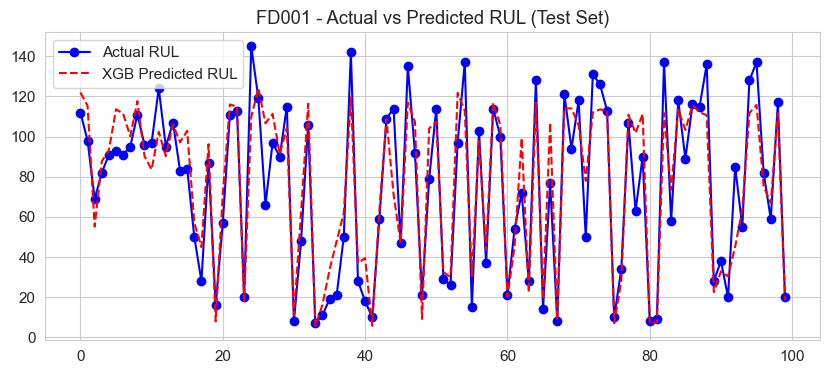

========== [FD002] FINAL TRAINING ==========
RESULTS for FD002:
   Train RMSE: 15.293
   Test RMSE:  27.538

TOP 10 FEATURES:
sensor_6_roll_mean    0.177079
sensor_6              0.104238
sensor_4              0.100500
sensor_17             0.083076
sensor_3              0.082194
sensor_2              0.063858
sensor_6_lag1         0.063535
sensor_20             0.050995
sensor_8              0.034743
sensor_9              0.027898
dtype: float32


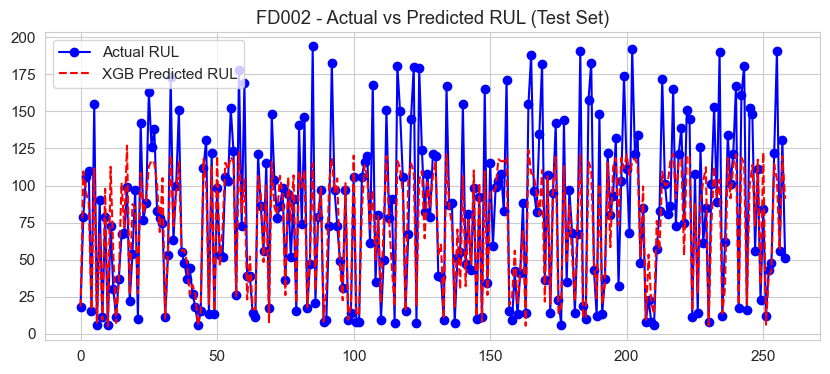

========== [FD003] FINAL TRAINING ==========
RESULTS for FD003:
   Train RMSE: 13.132
   Test RMSE:  16.716

TOP 10 FEATURES:
sensor_3              0.195518
sensor_8              0.159440
sensor_2              0.084286
sensor_9              0.065062
sensor_9_trend        0.061110
sensor_14_roll_std    0.056029
sensor_15             0.049034
sensor_9_roll_std     0.046229
sensor_12_trend       0.037659
sensor_11_trend       0.035734
dtype: float32


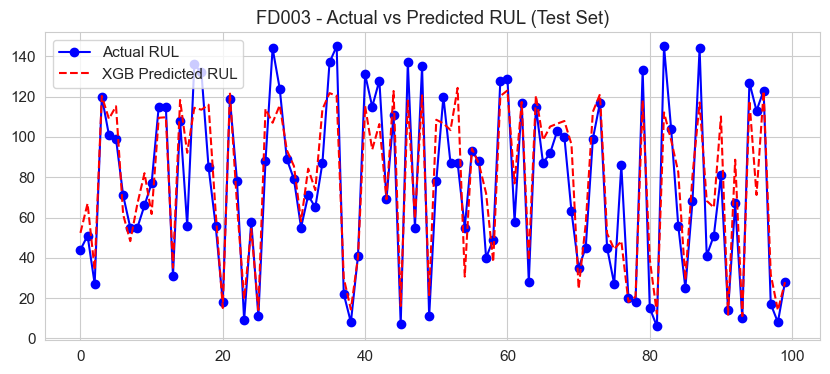

========== [FD004] FINAL TRAINING ==========
RESULTS for FD004:
   Train RMSE: 15.323
   Test RMSE:  28.604

TOP 10 FEATURES:
sensor_3              0.224078
sensor_17_cumax       0.105694
sensor_2              0.094262
sensor_8              0.085099
sensor_4              0.076748
sensor_14_roll_std    0.076712
sensor_7              0.048279
sensor_14_trend       0.035606
sensor_11_roll_std    0.027161
sensor_15             0.026897
dtype: float32


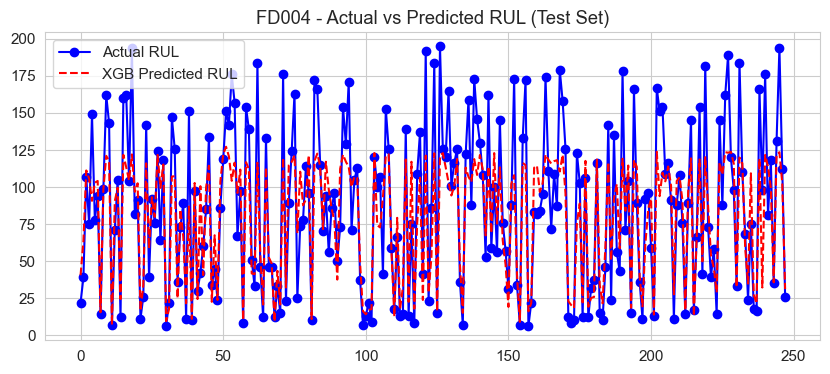


ALL MODELS TRAINED AND EVALUATED.


In [277]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

print("STEP 2: FINAL TRAINING & EVALUATION\n")

# Điều chỉnh lại Step 2
for fd in target_fds:
    print(f"========== [{fd}] FINAL TRAINING ==========")
    md = modeling_datasets[fd]
    best_params = best_params_dict[fd]

    # Khởi tạo model: Đưa early_stopping_rounds vào đây
    model = XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror',
        early_stopping_rounds=25, # DI CHUYỂN VÀO ĐÂY
        **best_params
    )

    # Khi fit, bỏ tham số early_stopping_rounds đi
    model.fit(
        md['X_train'], md['y_train'],
        eval_set=[(md['X_test'], md['y_test'])],
        verbose=False 
    )

    # Các bước sau giữ nguyên...
    y_train_pred = model.predict(md['X_train'])
    y_test_pred = model.predict(md['X_test'])

    # Tính toán Metrics
    rmse_train = np.sqrt(mean_squared_error(md['y_train'], y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(md['y_test'], y_test_pred))

    print(f"RESULTS for {fd}:")
    print(f"   Train RMSE: {rmse_train:.3f}")
    print(f"   Test RMSE:  {rmse_test:.3f}")

    # Feature Importance (Top 10)
    importances = model.feature_importances_
    feat_imp = pd.Series(importances, index=md['X_train'].columns).sort_values(ascending=False).head(10)
    
    print(f"\nTOP 10 FEATURES:")
    print(feat_imp)
    
    # Lưu kết quả dự báo để so sánh với Deep Learning sau này
    modeling_datasets[fd]['xgb_preds'] = y_test_pred
    modeling_datasets[fd]['xgb_model'] = model

    # Vẽ biểu đồ so sánh nhanh
    plt.figure(figsize=(10, 4))
    plt.plot(md['y_test'], label='Actual RUL', color='blue', marker='o')
    plt.plot(y_test_pred, label='XGB Predicted RUL', color='red', linestyle='--')
    plt.title(f"{fd} - Actual vs Predicted RUL (Test Set)")
    plt.legend()
    plt.show()

print("\nALL MODELS TRAINED AND EVALUATED.")    

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

print("STEP 1: TUNING RANDOM FOREST PARAMETERS")

rf_param_grid = {
    'max_depth': [5, 7, 8],                # Giảm thêm: Cây càng nông thì càng khó "học vẹt"
    'min_samples_leaf': [150, 200, 300],   # Tăng mạnh: Ép mỗi lá cây phải đại diện cho một nhóm dữ liệu cực lớn
    'max_features': [0.2, 0.3],            # Giảm: Chỉ cho phép chọn 20-30% số lượng sensor cho mỗi lần tách nhánh
    'min_samples_split': [300, 400],       # Ép: Phải có rất nhiều dữ liệu mới được phép chia thêm nhánh
    'max_samples': [0.5, 0.6],             # Giấy phép "học": Mỗi cây chỉ được thấy 50-60% dữ liệu Train
    'bootstrap': [True]
}

rf_best_params_dict = {}

for fd in target_fds:
    print(f"Tuning for {fd}...")
    md = modeling_datasets[fd]
    
    # Khởi tạo RF cơ bản để tìm cấu trúc cây tối ưu
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=rf_param_grid,
        cv=3,
        scoring='neg_root_mean_squared_error',
        verbose=1
    )
    
    grid_search.fit(md['X_train'], md['y_train'])
    rf_best_params_dict[fd] = grid_search.best_params_
    print(f"Best params for {fd}: {grid_search.best_params_}")

STEP 1: TUNING RANDOM FOREST PARAMETERS
Tuning for FD001...
Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params for FD001: {'bootstrap': True, 'max_depth': 7, 'max_features': 0.3, 'max_samples': 0.6, 'min_samples_leaf': 150, 'min_samples_split': 300}
Tuning for FD002...
Fitting 3 folds for each of 72 candidates, totalling 216 fits


In [282]:
import numpy as np
from sklearn.metrics import mean_squared_error

print("STEP 2: RF TRAINING WITH MANUAL EARLY STOPPING\n")

rf_final_results = []

for fd in target_fds:
    print(f"========== [{fd}] RF FINAL TRAINING ==========")
    md = modeling_datasets[fd]
    params = rf_best_params_dict[fd]
    
    # Khởi tạo model với cấu trúc cây đã tuned
    # warm_start=True cho phép chúng ta thêm cây vào model cũ
    rf_model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1,
        warm_start=True 
    )

    best_test_rmse = float('inf')
    stop_count = 0
    patience = 5  # Giống như early_stopping_rounds
    step_trees = 50 # Mỗi bước thêm 50 cây
    
    for i in range(1, 21): # Tối đa 1000 cây (20 * 50)
        rf_model.n_estimators = i * step_trees
        rf_model.fit(md['X_train'], md['y_train'])
        
        preds = rf_model.predict(md['X_test'])
        current_rmse = np.sqrt(mean_squared_error(md['y_test'], preds))
        
        if current_rmse < best_test_rmse:
            best_test_rmse = current_rmse
            stop_count = 0
        else:
            stop_count += 1
            
        if stop_count >= patience:
            print(f"Early stopping triggered at {rf_model.n_estimators} trees.")
            break
            
    # Đánh giá cuối cùng
    y_train_pred = rf_model.predict(md['X_train'])
    y_test_pred = rf_model.predict(md['X_test'])
    
    rmse_train = np.sqrt(mean_squared_error(md['y_train'], y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(md['y_test'], y_test_pred))
    
    print(f"RF RESULTS for {fd}:")
    print(f"   Train RMSE: {rmse_train:.3f}")
    print(f"   Test RMSE:  {rmse_test:.3f}")
    
    # Lưu kết quả để so sánh
    rf_final_results.append({
        'Dataset': fd,
        'RF_Train_RMSE': round(rmse_train, 3),
        'RF_Test_RMSE': round(rmse_test, 3),
        'RF_Overfit_Ratio': round(rmse_test/rmse_train, 2)
    })

# Hiển thị bảng so sánh RF
import pandas as pd
display(pd.DataFrame(rf_final_results))

STEP 2: RF TRAINING WITH MANUAL EARLY STOPPING

========== [FD001] RF FINAL TRAINING ==========
Early stopping triggered at 450 trees.
RF RESULTS for FD001:
   Train RMSE: 11.518
   Test RMSE:  15.100
========== [FD002] RF FINAL TRAINING ==========
Early stopping triggered at 400 trees.
RF RESULTS for FD002:
   Train RMSE: 11.547
   Test RMSE:  26.804
========== [FD003] RF FINAL TRAINING ==========
Early stopping triggered at 400 trees.
RF RESULTS for FD003:
   Train RMSE: 9.267
   Test RMSE:  15.141
========== [FD004] RF FINAL TRAINING ==========
Early stopping triggered at 300 trees.
RF RESULTS for FD004:
   Train RMSE: 12.061
   Test RMSE:  27.930


,Dataset,RF_Train_RMSE,RF_Test_RMSE,RF_Overfit_Ratio
0,FD001,11.518,15.100,1.31
1,FD002,11.547,26.804,2.32
2,FD003,9.267,15.141,1.63
3,FD004,12.061,27.930,2.32
